### Train Yolov11

In [ ]:
from ultralytics import YOLO

# Load a model
path_to_yolo = r"D:\Magistrska\blindoff-magistrska\fitcode-frontend-next\public\models\yolov11\256\yolo11n-pose_256.pt"
path_to_config = r"D:\Magistrska\blindoff-dataset\data.yaml"
model = YOLO(path_to_yolo)  # load a pretrained model (recommended for training)

# Train the model
results = model.train(
    data=path_to_config, imgsz=256, epochs=200, device=0, save_period=10
)

New https://pypi.org/project/ultralytics/8.4.12 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.236  Python-3.8.20 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Magistrska\blindoff-dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\Magistrska\blindoff-magistrska\fitcode-frontend-next\public\models\yolov11\25

### Plots

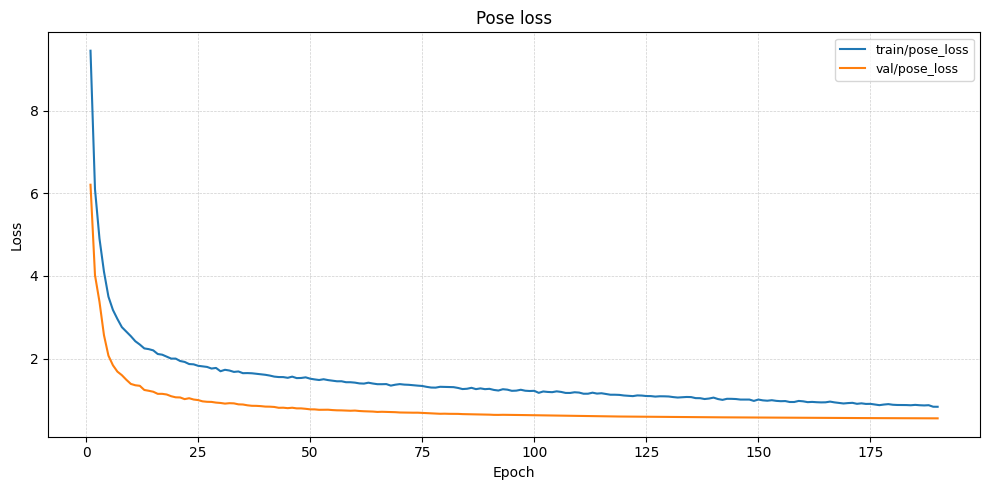

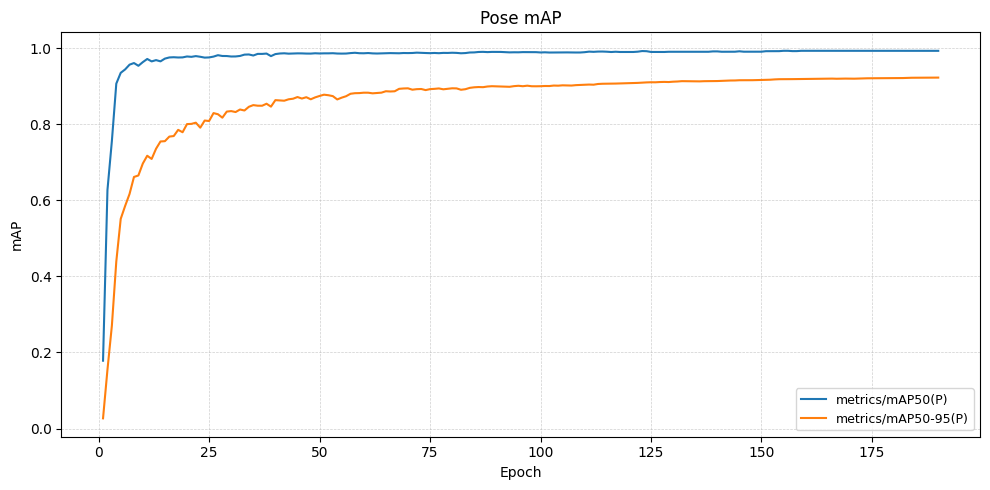

,epoch,time,train/box_loss,train/pose_loss,train/kobj_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(P),metrics/mAP50-95(P),val/box_loss,val/pose_loss,val/kobj_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,99.2721,1.09131,9.45682,0,0.76761,1.09687,0.94901,0.97652,0.98452,...,0.17838,0.02678,0.60213,6.21002,0,0.44375,0.85370,0.003326,0.003326,0.003326
1,2,189.6760,0.83446,6.10157,0,0.59537,0.97872,0.95586,0.97078,0.98776,...,0.62739,0.15471,0.54376,4.01895,0,0.43434,0.84118,0.006627,0.006627,0.006627
2,3,277.5000,0.87813,4.90619,0,0.62328,0.99650,0.93631,0.97280,0.98056,...,0.75625,0.27054,0.61635,3.37548,0,0.47511,0.85908,0.009894,0.009894,0.009894
3,4,364.8200,0.89136,4.10611,0,0.63714,1.00580,0.94014,0.98506,0.98115,...,0.90707,0.43931,0.58804,2.56761,0,0.46418,0.85848,0.009851,0.009851,0.009851
4,5,452.0600,0.85549,3.49874,0,0.61559,0.99207,0.95535,0.97972,0.98220,...,0.93546,0.55138,0.56125,2.06979,0,0.43786,0.85902,0.009802,0.009802,0.009802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,186,16770.3000,0.38885,0.86814,0,0.27298,0.86591,0.98405,0.98719,0.99443,...,0.99336,0.92253,0.22317,0.55183,0,0.17772,0.78221,0.000843,0.000843,0.000843
186,187,16861.4000,0.38367,0.86363,0,0.27299,0.86570,0.98405,0.98772,0.99443,...,0.99339,0.92265,0.22292,0.55157,0,0.17740,0.78218,0.000793,0.000793,0.000793
187,188,16950.4000,0.38218,0.86917,0,0.27230,0.86542,0.98405,0.98745,0.99444,...,0.99336,0.92278,0.22288,0.55135,0,0.17724,0.78215,0.000744,0.000744,0.000744
188,189,17040.8000,0.37645,0.83206,0,0.26755,0.86387,0.98509,0.98826,0.99443,...,0.99335,0.92268,0.22296,0.55104,0,0.17756,0.78214,0.000694,0.000694,0.000694


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Optional

file_path = r"D:\Magistrska\blindoff-magistrska\notebooks\runs\pose\train\results.csv" 


def plot_columns_over_epochs(
    columns: List[str],
    csv_path: str = file_path,
    title: Optional[str] = None,
    xlabel: str = "Epoch",
    ylabel: str = "Value",
    show: bool = True,
    save_path: Optional[str] = None,
):
    df = pd.read_csv(csv_path)

    if "epoch" not in df.columns:
        raise ValueError("CSV must contain an 'epoch' column.")

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}\nAvailable: {list(df.columns)}")

    x = df["epoch"].to_numpy()

    plt.figure(figsize=(10, 5))
    for c in columns:
        y = pd.to_numeric(df[c], errors="coerce").to_numpy()
        plt.plot(x, y, label=c)

    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title or "Metrike skozi epohe")
    plt.legend(fontsize=9)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)

    if show:
        plt.show()

    return df


# --- Examples ---
# 1) Pose loss (train vs val)
plot_columns_over_epochs(
    ["train/pose_loss", "val/pose_loss"],
    title="Pose loss",
    ylabel="Loss",
    save_path="pose_loss.png"
)

# 2) Pose mAP metrics
plot_columns_over_epochs(
    ["metrics/mAP50(P)", "metrics/mAP50-95(P)"],
    title="Pose mAP",
    ylabel="mAP",
    save_path="pose_map.png"
)

### Convert to tfjs

In [1]:
from ultralytics import YOLO

# Load the YOLO26 model
model_path = r'D:\Magistrska\blindoff-magistrska\notebooks\runs\pose\train\weights\best.pt'
model = YOLO(model_path)

# Export the model to TF.js format
model.export(format="tfjs", imgsz=256)  # or 640 if you prefer

Ultralytics 8.3.236  Python-3.8.20 torch-2.1.2+cu118 CPU (AMD Ryzen 7 4800H with Radeon Graphics)
YOLO11n-pose summary (fused): 109 layers, 2,754,421 parameters, 0 gradients, 6.9 GFLOPs

PyTorch: starting from 'D:\Magistrska\blindoff-magistrska\notebooks\runs\pose\train\weights\best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 39, 1344) (10.9 MB)
requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3', 'protobuf>=5'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command 'pip install --no-cache-dir "tf_keras<=2.19.0" "ai-edge-litert>=1.2.0" "onnx2tf>=1.26.3" "protobuf>=5" --extra-index-url https://pypi.ngc.nvidia.com' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command 'pip install --no-cache-dir "tf_keras<=2.19.0" "ai-edge-litert>=1.2.0" "onnx2tf>=1.26.3" "protobuf>=5" --extra-index-url https://pypi.ngc.nvidia.com' returned non-zero exit status 1.
WARNING requirements:  Command 'pip inst

AttributeError: 'tuple' object has no attribute 'tb_frame'